<a href="https://colab.research.google.com/github/UrmishaPal/FAERS-Pipeline/blob/main/FAERS_Adverse_Event_Analysis_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

identify what collab sees

In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        print(os.path.join(root, file))

/content/RPSR26Q2.txt
/content/DEMO26Q2.txt
/content/THER26Q2.pdf
/content/DRUG26Q2.txt
/content/DRUG26Q2.pdf
/content/OUTC26Q2.pdf
/content/DEMO26Q2.pdf
/content/OUTC26Q2.txt
/content/ASC_NTS.pdf
/content/THER26Q2.txt
/content/REAC26Q2.txt
/content/RPSR26Q2.pdf
/content/.config/.last_opt_in_prompt.yaml
/content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
/content/.config/.last_survey_prompt.yaml
/content/.config/.last_update_check.json
/content/.config/active_config
/content/.config/gce
/content/.config/default_configs.db
/content/.config/config_sentinel
/content/.config/configurations/config_default
/content/.config/logs/2026.08.24/13.21.29.508618.log
/content/.config/logs/2026.08.24/13.21.51.486625.log
/content/.config/logs/2026.08.24/13.21.04.810117.log
/content/.config/logs/2026.08.24/13.21.50.716841.log
/content/.config/logs/2026.08.24/13.21.39.096390.log
/content/.config/logs/2026.08.24/13.21.40.570084.log
/content/sample_data/anscombe.json
/content/sa

In [ ]:
import pandas as pd
import numpy as np
import os
import gc

load demo

In [ ]:
demo = pd.read_csv(
    "/content/DEMO26Q2.txt",
    sep="$",
    dtype=str,
    encoding="latin1",
    low_memory=True
)

print("DEMO loaded successfully")
print("Rows:", len(demo))
print("Columns:", len(demo.columns))

DEMO loaded successfully
Rows: 127745
Columns: 25


In [ ]:
print(type(demo))

<class 'pandas.core.frame.DataFrame'>


In [ ]:
print(demo.columns)

Index(['primaryid', 'caseid', 'caseversion', 'i_f_code', 'event_dt', 'mfr_dt',
       'init_fda_dt', 'fda_dt', 'rept_cod', 'auth_num', 'mfr_num', 'mfr_sndr',
       'lit_ref', 'age', 'age_cod', 'age_grp', 'sex', 'e_sub', 'wt', 'wt_cod',
       'rept_dt', 'to_mfr', 'occp_cod', 'reporter_country', 'occr_country'],
      dtype='object')


In [ ]:
print("DEMO shape:", demo.shape)

DEMO shape: (127745, 25)


In [ ]:
print(demo.columns.tolist())

['primaryid', 'caseid', 'caseversion', 'i_f_code', 'event_dt', 'mfr_dt', 'init_fda_dt', 'fda_dt', 'rept_cod', 'auth_num', 'mfr_num', 'mfr_sndr', 'lit_ref', 'age', 'age_cod', 'age_grp', 'sex', 'e_sub', 'wt', 'wt_cod', 'rept_dt', 'to_mfr', 'occp_cod', 'reporter_country', 'occr_country']


In [ ]:
demo.head(3)

,primaryid,caseid,caseversion,i_f_code,event_dt,mfr_dt,init_fda_dt,fda_dt,rept_cod,auth_num,...,age_grp,sex,e_sub,wt,wt_cod,rept_dt,to_mfr,occp_cod,reporter_country,occr_country
0,100140224,10014022,4,F,NaN,20260508,20140317,20260513,EXP,NaN,...,E,M,Y,83,KG,20260513,NaN,MD,EU,EU
1,100218353,10021835,3,F,NaN,20260528,20140319,20260603,EXP,NaN,...,T,M,Y,NaN,NaN,20260603,NaN,LW,US,US
2,101009832,10100983,2,F,NaN,20140402,20140424,20260624,EXP,NaN,...,NaN,NaN,Y,NaN,NaN,20260624,NaN,MD,EU,EU


In [ ]:
print(demo.columns.tolist())

['primaryid', 'caseid', 'caseversion', 'i_f_code', 'event_dt', 'mfr_dt', 'init_fda_dt', 'fda_dt', 'rept_cod', 'auth_num', 'mfr_num', 'mfr_sndr', 'lit_ref', 'age', 'age_cod', 'age_grp', 'sex', 'e_sub', 'wt', 'wt_cod', 'rept_dt', 'to_mfr', 'occp_cod', 'reporter_country', 'occr_country']


In [ ]:
demo_drug = demo.copy()

print("demo_drug created successfully")
print(demo_drug.shape)
print(demo_drug.head())

demo_drug created successfully
(127745, 25)
   primaryid    caseid caseversion i_f_code event_dt    mfr_dt init_fda_dt  \
0  100140224  10014022           4        F      NaN  20260508    20140317   
1  100218353  10021835           3        F      NaN  20260528    20140319   
2  101009832  10100983           2        F      NaN  20140402    20140424   
3  101447083  10144708           3        F      NaN  20130103    20251230   
4  101447143  10144714           3        F      NaN  20140321    20251230   

     fda_dt rept_cod auth_num  ... age_grp  sex e_sub   wt wt_cod   rept_dt  \
0  20260513      EXP      NaN  ...       E    M     Y   83     KG  20260513   
1  20260603      EXP      NaN  ...       T    M     Y  NaN    NaN  20260603   
2  20260624      EXP      NaN  ...     NaN  NaN     Y  NaN    NaN  20260624   
3  20251230      PER      NaN  ...     NaN  NaN     Y  NaN    NaN  20260628   
4  20251230      PER      NaN  ...     NaN  NaN     Y  NaN    NaN  20260628   

  to_mfr occ

In [ ]:
print(demo_drug.columns.tolist())

['primaryid', 'caseid', 'caseversion', 'i_f_code', 'event_dt', 'mfr_dt', 'init_fda_dt', 'fda_dt', 'rept_cod', 'auth_num', 'mfr_num', 'mfr_sndr', 'lit_ref', 'age', 'age_cod', 'age_grp', 'sex', 'e_sub', 'wt', 'wt_cod', 'rept_dt', 'to_mfr', 'occp_cod', 'reporter_country', 'occr_country']


In [ ]:
print([x for x in globals() if not x.startswith("_")])

['In', 'Out', 'get_ipython', 'exit', 'quit', 'os', 'root', 'dirs', 'files', 'file', 'pd', 'np', 'gc', 'demo', 'demo_drug']


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'RPSR26Q2.txt', 'DEMO26Q2.txt', 'THER26Q2.pdf', 'DRUG26Q2.txt', 'DRUG26Q2.pdf', 'OUTC26Q2.pdf', 'REAC26Q2.pdf', 'INDI26Q2.txt', 'DEMO26Q2.pdf', 'OUTC26Q2.txt', 'ASC_NTS.pdf', 'THER26Q2.txt', 'REAC26Q2.txt', 'RPSR26Q2.pdf', 'INDI26Q2.pdf', 'sample_data']


In [ ]:
drug = pd.read_csv(
    "/content/DRUG26Q2.txt",
    sep="$",
    dtype=str,
    low_memory=False
)

print(drug.shape)
print(drug.columns.tolist())

(1292384, 20)
['primaryid', 'caseid', 'drug_seq', 'role_cod', 'drugname', 'prod_ai', 'val_vbm', 'route', 'dose_vbm', 'cum_dose_chr', 'cum_dose_unit', 'dechal', 'rechal', 'lot_num', 'exp_dt', 'nda_num', 'dose_amt', 'dose_unit', 'dose_form', 'dose_freq']


In [ ]:
print(drug.shape)
print(drug.columns.tolist())

(1292384, 20)
['primaryid', 'caseid', 'drug_seq', 'role_cod', 'drugname', 'prod_ai', 'val_vbm', 'route', 'dose_vbm', 'cum_dose_chr', 'cum_dose_unit', 'dechal', 'rechal', 'lot_num', 'exp_dt', 'nda_num', 'dose_amt', 'dose_unit', 'dose_form', 'dose_freq']


In [ ]:
demo_drug = demo.merge(
    drug,
    on=["primaryid", "caseid"],
    how="inner"
)

print(demo_drug.shape)
print(demo_drug.head())

(709793, 43)
   primaryid    caseid caseversion i_f_code event_dt    mfr_dt init_fda_dt  \
0  100140224  10014022           4        F      NaN  20260508    20140317   
1  100140224  10014022           4        F      NaN  20260508    20140317   
2  100140224  10014022           4        F      NaN  20260508    20140317   
3  100140224  10014022           4        F      NaN  20260508    20140317   
4  100140224  10014022           4        F      NaN  20260508    20140317   

     fda_dt rept_cod auth_num  ... cum_dose_unit dechal rechal lot_num exp_dt  \
0  20260513      EXP      NaN  ...           NaN      Y      U     NaN    NaN   
1  20260513      EXP      NaN  ...           NaN      Y      U     NaN    NaN   
2  20260513      EXP      NaN  ...           NaN      Y      U     NaN    NaN   
3  20260513      EXP      NaN  ...           NaN      U    NaN     NaN    NaN   
4  20260513      EXP      NaN  ...           NaN    NaN    NaN     NaN    NaN   

  nda_num dose_amt dose_unit   

In [ ]:
reac = pd.read_csv(
    "/content/REAC26Q2.txt",
    sep="$",
    dtype=str,
    low_memory=False
)

print(reac.shape)
print(reac.columns.tolist())

(1394751, 4)
['primaryid', 'caseid', 'pt', 'drug_rec_act']


In [ ]:
case_drug_reac = demo_drug.merge(
    reac,
    on=["primaryid", "caseid"],
    how="inner"
)

print(case_drug_reac.shape)

In [ ]:
import pandas as pd
import os

print("Runtime connected")
print(os.listdir("/content"))

Runtime connected
['.config', 'RPSR26Q2.txt', 'DEMO26Q2.txt', 'THER26Q2.pdf', 'DRUG26Q2.txt', 'DRUG26Q2.pdf', 'OUTC26Q2.pdf', 'REAC26Q2.pdf', 'INDI26Q2.txt', 'DEMO26Q2.pdf', 'OUTC26Q2.txt', 'ASC_NTS.pdf', 'THER26Q2.txt', 'REAC26Q2.txt', 'RPSR26Q2.pdf', 'INDI26Q2.pdf', 'sample_data']


In [ ]:
chunks = []

for chunk in pd.read_csv(
    "/content/DRUG26Q2.txt",
    sep="$",
    dtype=str,
    chunksize=50000,
    low_memory=False
):
    chunks.append(chunk)

drug = pd.concat(chunks, ignore_index=True)

In [ ]:
import pandas as pd
import os

print("Runtime connected")
print(os.listdir("/content"))

Runtime connected
['.config', 'RPSR26Q2.txt', 'DEMO26Q2.txt', 'THER26Q2.pdf', 'DRUG26Q2.txt', 'DRUG26Q2.pdf', 'OUTC26Q2.pdf', 'REAC26Q2.pdf', 'INDI26Q2.txt', 'DEMO26Q2.pdf', 'OUTC26Q2.txt', 'ASC_NTS.pdf', 'THER26Q2.txt', 'REAC26Q2.txt', 'RPSR26Q2.pdf', 'INDI26Q2.pdf', 'sample_data']


In [ ]:
demo_chunks = []

for chunk in pd.read_csv(
    "/content/DEMO26Q2.txt",
    sep="$",
    dtype=str,
    chunksize=50000,
    low_memory=False
):
    demo_chunks.append(chunk)

demo = pd.concat(demo_chunks, ignore_index=True)

print("DEMO loaded:", demo.shape)

DEMO loaded: (422459, 25)


In [ ]:
drug_columns = pd.read_csv(
    "/content/DRUG26Q2.txt",
    sep="$",
    nrows=0
).columns.tolist()

print(drug_columns)

['primaryid', 'caseid', 'drug_seq', 'role_cod', 'drugname', 'prod_ai', 'val_vbm', 'route', 'dose_vbm', 'cum_dose_chr', 'cum_dose_unit', 'dechal', 'rechal', 'lot_num', 'exp_dt', 'nda_num', 'dose_amt', 'dose_unit', 'dose_form', 'dose_freq']


In [ ]:
drug_chunks = []

for chunk in pd.read_csv(
    "/content/DRUG26Q2.txt",
    sep="$",
    usecols=["primaryid", "caseid", "drugname", "drug_seq", "role_cod"],
    dtype=str,
    chunksize=50000,
    low_memory=False
):
    drug_chunks.append(chunk)

drug = pd.concat(drug_chunks, ignore_index=True)

print("DRUG loaded:", drug.shape)
print(drug.head())

DRUG loaded: (1627225, 5)
   primaryid    caseid drug_seq role_cod               drugname
0  100140224  10014022        1       PS  PEGINTERFERON ALFA-2A
1  100140224  10014022        2       SS                COPEGUS
2  100140224  10014022        3       SS              VICTRELIS
3  100140224  10014022        4        C              CAPTOPRIL
4  100140224  10014022        5        C              METFORMIN


In [ ]:
reac_chunks = []

for chunk in pd.read_csv(
    "/content/REAC26Q2.txt",
    sep="$",
    usecols=["primaryid", "caseid", "pt"],
    dtype=str,
    chunksize=50000,
    low_memory=False
):
    reac_chunks.append(chunk)

reac = pd.concat(reac_chunks, ignore_index=True)

print("REAC loaded:", reac.shape)
print(reac.head())

REAC loaded: (1394751, 3)
   primaryid    caseid                   pt
0  100140224  10014022  Toxic skin eruption
1  100218353  10021835   Emotional disorder
2  100218353  10021835        Gynaecomastia
3  100218353  10021835     Weight increased
4  100218353  10021835   Tardive dyskinesia


In [ ]:
drug_reac = drug.merge(
    reac,
    on=["primaryid", "caseid"],
    how="inner"
)

print("DRUG-REAC shape:", drug_reac.shape)
print(drug_reac.head())

DRUG-REAC shape: (17505986, 6)
   primaryid    caseid drug_seq role_cod               drugname  \
0  100140224  10014022        1       PS  PEGINTERFERON ALFA-2A   
1  100140224  10014022        2       SS                COPEGUS   
2  100140224  10014022        3       SS              VICTRELIS   
3  100140224  10014022        4        C              CAPTOPRIL   
4  100140224  10014022        5        C              METFORMIN   

                    pt  
0  Toxic skin eruption  
1  Toxic skin eruption  
2  Toxic skin eruption  
3  Toxic skin eruption  
4  Toxic skin eruption  


In [ ]:
print(demo.columns.tolist())

['primaryid', 'caseid', 'caseversion', 'i_f_code', 'event_dt', 'mfr_dt', 'init_fda_dt', 'fda_dt', 'rept_cod', 'auth_num', 'mfr_num', 'mfr_sndr', 'lit_ref', 'age', 'age_cod', 'age_grp', 'sex', 'e_sub', 'wt', 'wt_cod', 'rept_dt', 'to_mfr', 'occp_cod', 'reporter_country', 'occr_country']


In [ ]:
wanted_cols = [
    "primaryid", "caseid", "age", "age_cod", "sex",
    "event_dt", "report_dt", "country", "reporter_country", "occp_cod"
]

available_cols = [col for col in wanted_cols if col in demo.columns]

demo_small = demo[available_cols].copy()

print("Columns used:", available_cols)
print("DEMO small shape:", demo_small.shape)

Columns used: ['primaryid', 'caseid', 'age', 'age_cod', 'sex', 'event_dt', 'reporter_country', 'occp_cod']
DEMO small shape: (422459, 8)


In [ ]:
print("demo_small:", demo_small.shape)
print("drug_reac:", drug_reac.shape)

print("DEMO keys:")
print([c for c in ["primaryid", "caseid"] if c in demo_small.columns])

print("DRUG-REAC keys:")
print([c for c in ["primaryid", "caseid"] if c in drug_reac.columns])

demo_small: (422459, 8)
drug_reac: (17505986, 6)
DEMO keys:
['primaryid', 'caseid']
DRUG-REAC keys:
['primaryid', 'caseid']


In [ ]:
case_drug_reac = demo_small.merge(
    drug_reac,
    on=["primaryid", "caseid"],
    how="inner"
)

print("Final merged dataset:", case_drug_reac.shape)
print(case_drug_reac.head())

Final merged dataset: (17505986, 12)
   primaryid    caseid age age_cod sex event_dt reporter_country occp_cod  \
0  100140224  10014022  66      YR   M      NaN               EU       MD   
1  100140224  10014022  66      YR   M      NaN               EU       MD   
2  100140224  10014022  66      YR   M      NaN               EU       MD   
3  100140224  10014022  66      YR   M      NaN               EU       MD   
4  100140224  10014022  66      YR   M      NaN               EU       MD   

  drug_seq role_cod               drugname                   pt  
0        1       PS  PEGINTERFERON ALFA-2A  Toxic skin eruption  
1        2       SS                COPEGUS  Toxic skin eruption  
2        3       SS              VICTRELIS  Toxic skin eruption  
3        4        C              CAPTOPRIL  Toxic skin eruption  
4        5        C              METFORMIN  Toxic skin eruption  


In [ ]:
print(case_drug_reac.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17505986 entries, 0 to 17505985
Data columns (total 12 columns):
 #   Column            Dtype 
---  ------            ----- 
 0   primaryid         object
 1   caseid            object
 2   age               object
 3   age_cod           object
 4   sex               object
 5   event_dt          object
 6   reporter_country  object
 7   occp_cod          object
 8   drug_seq          object
 9   role_cod          object
 10  drugname          object
 11  pt                object
dtypes: object(12)
memory usage: 1.6+ GB
None


In [ ]:
print(case_drug_reac.shape)
print(case_drug_reac.columns.tolist())

(17505986, 12)
['primaryid', 'caseid', 'age', 'age_cod', 'sex', 'event_dt', 'reporter_country', 'occp_cod', 'drug_seq', 'role_cod', 'drugname', 'pt']


In [ ]:
print("Rows:", len(case_drug_reac))
print("Columns:", len(case_drug_reac.columns))
print("\nColumn names:")
print(case_drug_reac.columns.tolist())

Rows: 17505986
Columns: 12

Column names:
['primaryid', 'caseid', 'age', 'age_cod', 'sex', 'event_dt', 'reporter_country', 'occp_cod', 'drug_seq', 'role_cod', 'drugname', 'pt']


In [ ]:
print("\nFirst 5 records:")
display(case_drug_reac.head())


First 5 records:


,primaryid,caseid,age,age_cod,sex,event_dt,reporter_country,occp_cod,drug_seq,role_cod,drugname,pt
0,100140224,10014022,66,YR,M,NaN,EU,MD,1,PS,PEGINTERFERON ALFA-2A,Toxic skin eruption
1,100140224,10014022,66,YR,M,NaN,EU,MD,2,SS,COPEGUS,Toxic skin eruption
2,100140224,10014022,66,YR,M,NaN,EU,MD,3,SS,VICTRELIS,Toxic skin eruption
3,100140224,10014022,66,YR,M,NaN,EU,MD,4,C,CAPTOPRIL,Toxic skin eruption
4,100140224,10014022,66,YR,M,NaN,EU,MD,5,C,METFORMIN,Toxic skin eruption


In [ ]:
top_drugs = (
    case_drug_reac["drugname"]
    .value_counts()
    .head(20)
)

print("Top 20 Reported Drugs:")
print(top_drugs)

Top 20 Reported Drugs:
drugname
METHOTREXATE                467718
ACTEMRA                     380413
SULFASALAZINE               341321
PREDNISONE                  317850
FOLIC ACID                  279879
RITUXIMAB                   241625
LEFLUNOMIDE                 183845
DESOXIMETASONE              173446
DUPIXENT                    161635
INFLECTRA                   157441
ACETAMINOPHEN               154987
ORENCIA                     142901
CETIRIZINE HYDROCHLORIDE    139559
ENBREL                      136060
DICLOFENAC SODIUM           126070
PHTHALYLSULFATHIAZOLE       124007
INFLIXIMAB                  120832
HYDROXYCHLOROQUINE          113110
XELJANZ                     108119
CIMZIA                      101399
Name: count, dtype: int64


In [ ]:
top_reactions = (
    case_drug_reac["pt"]
    .value_counts()
    .head(20)
)

print("\nTop 20 Reported Adverse Reactions:")
print(top_reactions)


Top 20 Reported Adverse Reactions:
pt
Off label use                           270736
Fatigue                                 189289
Drug ineffective                        185059
Nausea                                  167916
Headache                                152712
Diarrhoea                               152659
Pain                                    145403
Dyspnoea                                141328
Vomiting                                128349
Condition aggravated                    128109
Arthralgia                              120379
Rash                                    119663
Dizziness                               112123
Pyrexia                                 107799
Pneumonia                               105215
Malaise                                 102488
Product use in unapproved indication     99406
Hypertension                             99137
Asthenia                                 97055
Pruritus                                 94540
Name: count, dtype: i

In [ ]:
drug_reaction_pairs = (
    case_drug_reac
    .groupby(["drugname", "pt"])
    .size()
    .reset_index(name="report_count")
    .sort_values("report_count", ascending=False)
)

print("Top 20 Drug–Reaction Pairs:")
print(drug_reaction_pairs.head(20))

Top 20 Drug–Reaction Pairs:
             drugname                                    pt  report_count
802073      INFLECTRA                         Off label use         14756
801888      INFLECTRA         Intentional product use issue         12395
533009       DUPIXENT                              Pruritus          9702
455942   DEPO-PROVERA                            Meningioma          8606
801525      INFLECTRA                  Condition aggravated          8326
531435       DUPIXENT                     Dermatitis atopic          6022
1009830  METHOTREXATE                         Off label use          5867
532173       DUPIXENT                   Injection site pain          5732
801367      INFLECTRA                            Arthralgia          5198
728554       HAEGARDA                 Hereditary angioedema          5166
531566       DUPIXENT                                Eczema          4803
533057       DUPIXENT                                  Rash          4748
1272909   

In [ ]:
drug_reaction_pairs.to_csv(
    "/content/faers_drug_reaction_pairs.csv",
    index=False
)

print("Saved successfully.")

Saved successfully.


In [ ]:
# ===== FAERS CORE ANALYSIS =====

# 1. Top drugs
top_drugs = (
    case_drug_reac["drugname"]
    .value_counts()
    .head(20)
)

# 2. Top adverse reactions
top_reactions = (
    case_drug_reac["pt"]
    .value_counts()
    .head(20)
)

# 3. Drug–reaction pairs
drug_reaction_pairs = (
    case_drug_reac
    .groupby(["drugname", "pt"])
    .size()
    .reset_index(name="report_count")
    .sort_values("report_count", ascending=False)
    .head(50)
)

# 4. Save outputs
top_drugs.to_csv("/content/top_20_drugs.csv")
top_reactions.to_csv("/content/top_20_reactions.csv")
drug_reaction_pairs.to_csv(
    "/content/top_drug_reaction_pairs.csv",
    index=False
)

print("========== FAERS CORE ANALYSIS ==========")
print("\nTOP 10 DRUGS")
print(top_drugs.head(10))

print("\nTOP 10 ADVERSE REACTIONS")
print(top_reactions.head(10))

print("\nTOP 20 DRUG–REACTION PAIRS")
print(drug_reaction_pairs.head(20))

print("\nAll three outputs saved successfully.")

========== FAERS CORE ANALYSIS ==========

TOP 10 DRUGS
drugname
METHOTREXATE      467718
ACTEMRA           380413
SULFASALAZINE     341321
PREDNISONE        317850
FOLIC ACID        279879
RITUXIMAB         241625
LEFLUNOMIDE       183845
DESOXIMETASONE    173446
DUPIXENT          161635
INFLECTRA         157441
Name: count, dtype: int64

TOP 10 ADVERSE REACTIONS
pt
Off label use           270736
Fatigue                 189289
Drug ineffective        185059
Nausea                  167916
Headache                152712
Diarrhoea               152659
Pain                    145403
Dyspnoea                141328
Vomiting                128349
Condition aggravated    128109
Name: count, dtype: int64

TOP 20 DRUG–REACTION PAIRS
             drugname                                    pt  report_count
802073      INFLECTRA                         Off label use         14756
801888      INFLECTRA         Intentional product use issue         12395
533009       DUPIXENT                       

In [ ]:
# ===== DEMOGRAPHIC + REPORT ANALYSIS =====

print("===== FAERS DATASET SUMMARY =====")
print("Total records:", len(case_drug_reac))
print("Unique cases:", case_drug_reac["caseid"].nunique())
print("Unique drugs:", case_drug_reac["drugname"].nunique())
print("Unique reactions:", case_drug_reac["pt"].nunique())

# Sex distribution — only if available
if "sex" in case_drug_reac.columns:
    print("\n===== SEX DISTRIBUTION =====")
    print(case_drug_reac["sex"].value_counts(dropna=False).head(10))

# Occupation distribution — only if available
if "occp_cod" in case_drug_reac.columns:
    print("\n===== REPORTER/OCCUPATION CODES =====")
    print(case_drug_reac["occp_cod"].value_counts(dropna=False).head(10))

# Age distribution — only if available
if "age" in case_drug_reac.columns:
    print("\n===== AGE SUMMARY =====")
    age = pd.to_numeric(case_drug_reac["age"], errors="coerce")
    print(age.describe())

print("\n===== ANALYSIS COMPLETE =====")

===== FAERS DATASET SUMMARY =====
Total records: 17505986
Unique cases: 422458
Unique drugs: 33609
Unique reactions: 12918

===== SEX DISTRIBUTION =====
sex
F      11270806
M       3669141
NaN     2566039
Name: count, dtype: int64

===== REPORTER/OCCUPATION CODES =====
occp_cod
NaN    13888653
MD      2896554
PH       286873
HP       242967
CN       110051
LW        80888
Name: count, dtype: int64

===== AGE SUMMARY =====
count    1.509834e+07
mean     5.300070e+01
std      1.978064e+01
min      0.000000e+00
25%      4.300000e+01
50%      4.500000e+01
75%      6.500000e+01
max      1.493900e+04
Name: age, dtype: float64

===== ANALYSIS COMPLETE =====


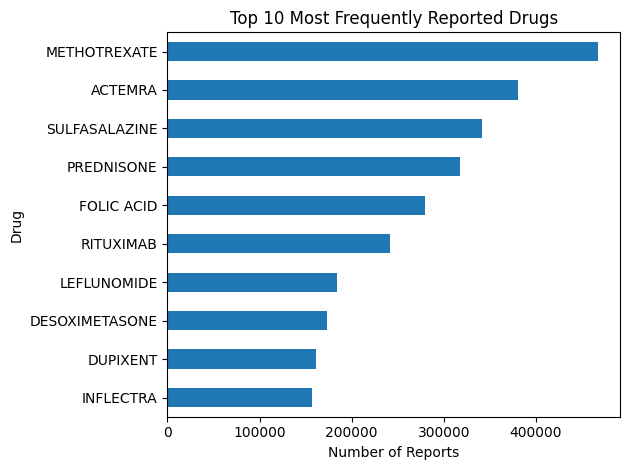

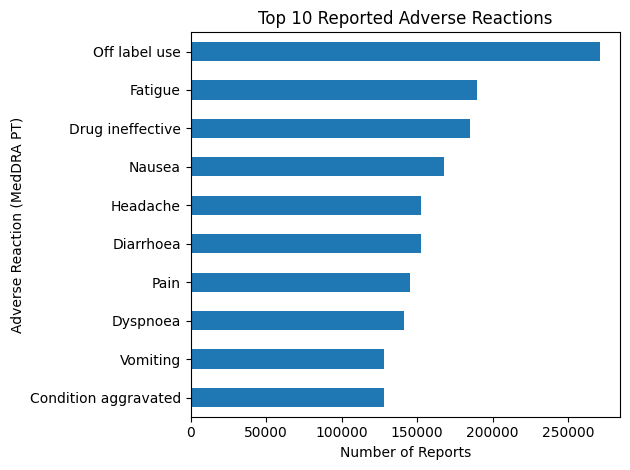

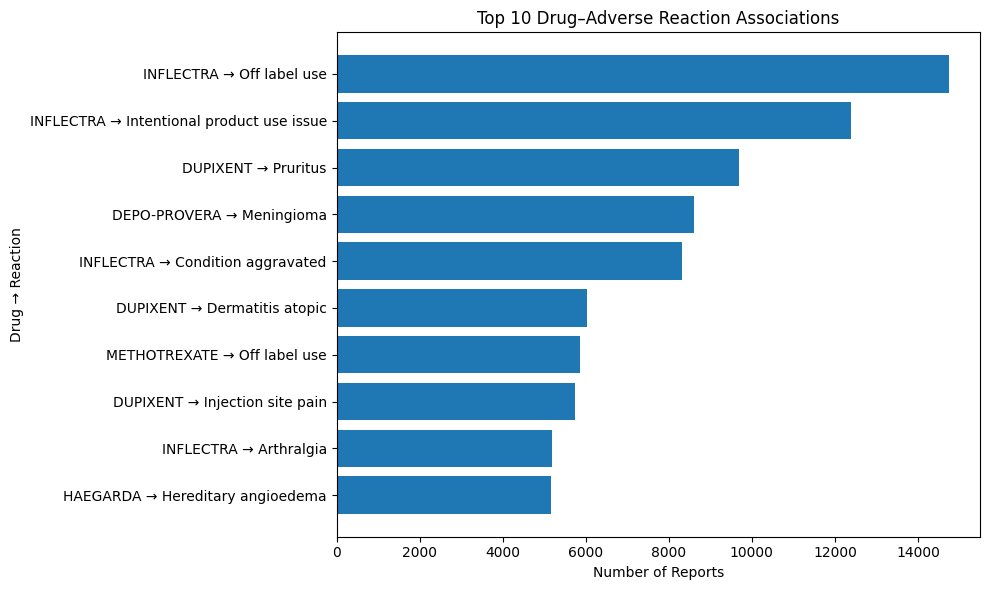

In [ ]:
import matplotlib.pyplot as plt

# ===== 1. TOP 10 DRUGS =====
top_drugs.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Most Frequently Reported Drugs")
plt.xlabel("Number of Reports")
plt.ylabel("Drug")
plt.tight_layout()
plt.show()


# ===== 2. TOP 10 ADVERSE REACTIONS =====
top_reactions.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Reported Adverse Reactions")
plt.xlabel("Number of Reports")
plt.ylabel("Adverse Reaction (MedDRA PT)")
plt.tight_layout()
plt.show()


# ===== 3. TOP 10 DRUG–REACTION PAIRS =====
top_pairs = drug_reaction_pairs.head(10).sort_values("report_count")

labels = (
    top_pairs["drugname"].astype(str)
    + " → "
    + top_pairs["pt"].astype(str)
)

plt.figure(figsize=(10, 6))
plt.barh(labels, top_pairs["report_count"])
plt.title("Top 10 Drug–Adverse Reaction Associations")
plt.xlabel("Number of Reports")
plt.ylabel("Drug → Reaction")
plt.tight_layout()
plt.show()

In [ ]:
# ===== SERIOUSNESS / OUTCOME ANALYSIS =====

# Show available outcome/seriousness columns
keywords = ["ser", "outc", "death", "hosp", "life", "disab", "cong", "interv"]

relevant_cols = [
    col for col in case_drug_reac.columns
    if any(k in col.lower() for k in keywords)
]

print("Relevant columns found:")
print(relevant_cols)

# Frequency tables for the relevant fields
for col in relevant_cols:
    print(f"\n===== {col} =====")
    print(case_drug_reac[col].value_counts(dropna=False).head(15))

Relevant columns found:
[]


In [ ]:
# ===== FINAL FAERS PROJECT EXPORT =====

# Save the main merged dataset
case_drug_reac.to_csv(
    "/content/FAERS_Q2_2026_merged_dataset.csv",
    index=False
)

# Save analysis outputs
top_drugs.to_csv(
    "/content/FAERS_top_drugs.csv",
    header=["report_count"]
)

top_reactions.to_csv(
    "/content/FAERS_top_adverse_reactions.csv",
    header=["report_count"]
)

drug_reaction_pairs.to_csv(
    "/content/FAERS_top_drug_reaction_pairs.csv",
    index=False
)

print("================================")
print("FAERS PROJECT FILES SAVED")
print("================================")

for file in [
    "FAERS_Q2_2026_merged_dataset.csv",
    "FAERS_top_drugs.csv",
    "FAERS_top_adverse_reactions.csv",
    "FAERS_top_drug_reaction_pairs.csv"
]:
    path = "/content/" + file
    print(f"{file} → {os.path.getsize(path) / (1024**2):.2f} MB")

FAERS PROJECT FILES SAVED
FAERS_Q2_2026_merged_dataset.csv → 1230.66 MB
FAERS_top_drugs.csv → 0.00 MB
FAERS_top_adverse_reactions.csv → 0.00 MB
FAERS_top_drug_reaction_pairs.csv → 0.00 MB


In [ ]:
import os

files = [
    "/content/FAERS_Q2_2026_merged_dataset.csv",
    "/content/FAERS_top_drugs.csv",
    "/content/FAERS_top_adverse_reactions.csv",
    "/content/FAERS_top_drug_reaction_pairs.csv"
]

for f in files:
    print("✅" if os.path.exists(f) else "❌", os.path.basename(f))

✅ FAERS_Q2_2026_merged_dataset.csv
✅ FAERS_top_drugs.csv
✅ FAERS_top_adverse_reactions.csv
✅ FAERS_top_drug_reaction_pairs.csv
